# Arabic Handwritten Word Recognition — Final Clean Version
**Run cells top to bottom. Do not skip any cell.**

## Cell 1 — Install

In [1]:
!pip install ultralytics opencv-python-headless matplotlib scikit-learn tensorflow-directml tqdm

## Cell 2 — Imports & Paths

In [27]:
import numpy as np
import cv2
import os
import re
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from ultralytics import YOLO

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Adjust ROOT to your project folder ───────────────────────
ROOT       = Path(r"F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN")
AHAWP_DIR  = ROOT / "isolated_alphabets_per_alphabet"
MY_CHARS   = ROOT / "my_chars"
MY_DATASET = ROOT / "my_dataset"
MNIST_TRAIN = ROOT / "arabic-chars-mnist" / "train"
MNIST_TEST  = ROOT / "arabic-chars-mnist" / "test"

IMG_SIZE = 32

# Standard 28 Arabic letter names
ARABIC_28 = [
    'ain','alef','beh','dad','dal','feh','ghain','hah','heh','jeem',
    'kaf','khah','lam','meem','noon','qaf','reh','sad','seen','sheen',
    'tah','teh','thal','theh','waw','yeh','zah','zain'
]

# AHAWP folder name → standard name
AHAWP_TO_STD = {
    'ain':'ain','alif':'alef','beh':'beh','dal':'dal','feh':'feh',
    'heh':'heh','jeem':'jeem','kaf':'kaf','lam':'lam','meem':'meem',
    'noon':'noon','qaf':'qaf','raa':'reh','sad':'sad','seen':'seen',
    'tah':'tah','waw':'waw','yaa':'yeh',
    # missing letters you added
    'dad':'dad','ghain':'ghain','hah':'hah','khah':'khah',
    'sheen':'sheen','teh':'teh','thal':'thal','theh':'theh',
    'zah':'zah','zain':'zain',
}

# my_chars folder name → standard name (Label Studio uses full form name)
MYCHARS_TO_STD = {
    'ain_beginning':'ain','ain_end':'ain','ain_middle':'ain','ain_isolated':'ain',
    'alif_end':'alef','alif_isolated':'alef','alif_hamza':'alef',
    'beh_beginning':'beh','beh_end':'beh','beh_middle':'beh','beh_isolated':'beh',
    'dad_beginning':'dad','dad_end':'dad','dad_middle':'dad','dad_isolated':'dad',
    'dal_end':'dal','dal_isolated':'dal',
    'feh_beginning':'feh','feh_end':'feh','feh_middle':'feh','feh_isolated':'feh',
    'ghain_beginning':'ghain','ghain_end':'ghain','ghain_middle':'ghain','ghain_isolated':'ghain',
    'hah_beginning':'hah','hah_end':'hah','hah_middle':'hah','hah_isolated':'hah',
    'heh_beginning':'heh','heh_end':'heh','heh_middle':'heh','heh_isolated':'heh',
    'jeem_beginning':'jeem','jeem_end':'jeem','jeem_middle':'jeem','jeem_isolated':'jeem',
    'kaf_beginning':'kaf','kaf_end':'kaf','kaf_middle':'kaf','kaf_isolated':'kaf',
    'khah_beginning':'khah','khah_end':'khah','khah_middle':'khah','khah_isolated':'khah',
    'lam_beginning':'lam','lam_end':'lam','lam_middle':'lam','lam_isolated':'lam','lam_alif':'lam',
    'meem_beginning':'meem','meem_end':'meem','meem_middle':'meem','meem_isolated':'meem',
    'noon_beginning':'noon','noon_end':'noon','noon_middle':'noon','noon_isolated':'noon',
    'qaf_beginning':'qaf','qaf_end':'qaf','qaf_middle':'qaf','qaf_isolated':'qaf',
    'raa_end':'reh','raa_isolated':'reh',
    'sad_beginning':'sad','sad_end':'sad','sad_middle':'sad','sad_isolated':'sad',
    'seen_beginning':'seen','seen_end':'seen','seen_middle':'seen','seen_isolated':'seen',
    'sheen_beginning':'sheen','sheen_end':'sheen','sheen_middle':'sheen','sheen_isolated':'sheen',
    'tah_end':'tah','tah_middle':'tah','tah_isolated':'tah',
    'teh_beginning':'teh','teh_end':'teh','teh_middle':'teh','teh_isolated':'teh',
    'thal_end':'thal','thal_isolated':'thal',
    'theh_beginning':'theh','theh_end':'theh','theh_middle':'theh','theh_isolated':'theh',
    'waw_end':'waw','waw_isolated':'waw',
    'yaa_beginning':'yeh','yaa_end':'yeh','yaa_middle':'yeh','yaa_isolated':'yeh',
    'zah_beginning':'zah','zah_end':'zah','zah_isolated':'zah',
    'zain_end':'zain','zain_isolated':'zain',
}

MISSING_10 = {'dad','ghain','hah','khah','sheen','teh','thal','theh','zah','zain'}

print(f"TensorFlow: {tf.__version__}")
for p in [ROOT, AHAWP_DIR, MY_DATASET]:
    print(f"{'OK' if p.exists() else 'MISSING'}: {p}")

TensorFlow: 2.21.0
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\isolated_alphabets_per_alphabet
OK: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset


## Cell 3 — Load All Data Sources

In [22]:
def load_grayscale_folder(folder, label_map, img_size=IMG_SIZE):
    """Load PNGs from subfolders. label_map maps subfolder name → standard label."""
    images, labels = [], []
    for subfolder in sorted(Path(folder).iterdir()):
        if not subfolder.is_dir():
            continue
        std = label_map.get(subfolder.name)
        if std is None:
            # Try stripping form suffix for AHAWP
            parts = subfolder.name.rsplit('_', 1)
            if len(parts) == 2:
                std = label_map.get(parts[0])
        if std is None:
            continue
        for img_path in subfolder.glob('*.png'):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            # Convert grayscale to BGR (3 channels)
            img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            images.append(img_bgr)
            labels.append(std)
    X = np.array(images, dtype='float32') / 255.0
    print(f"  {Path(folder).name}: {len(X)} images, {len(set(labels))} classes, shape {X.shape}")
    return X, np.array(labels)


def load_mnist_missing(train_path, test_path, missing_set=MISSING_10, img_size=IMG_SIZE):
    """Load Arabic MNIST images for missing letters only."""
    images, labels = [], []
    for path in [train_path, test_path]:
        if not Path(path).exists():
            continue
        for filename in os.listdir(path):
            label = re.sub('[0-9]+|\.jpg$', '', filename)
            if label not in missing_set:
                continue
            img = cv2.imread(os.path.join(path, filename))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (img_size, img_size))
            # Convert grayscale to BGR
            img_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
            images.append(img_bgr)
            labels.append(label)
    if not images:
        print("  Arabic MNIST missing: 0 images")
        return np.array([]).reshape(0, img_size, img_size, 3), np.array([])
    X = np.array(images, dtype='float32') / 255.0
    print(f"  Arabic MNIST (missing 10): {len(X)} images, {len(set(labels))} classes, shape {X.shape}")
    return X, np.array(labels)


print("Loading datasets...")
X_ahawp, y_ahawp = load_grayscale_folder(AHAWP_DIR,  AHAWP_TO_STD)
X_mine,  y_mine  = load_grayscale_folder(MY_CHARS,   MYCHARS_TO_STD) if MY_CHARS.exists() else (np.array([]).reshape(0,IMG_SIZE,IMG_SIZE,3), np.array([]))
X_mnist, y_mnist = load_mnist_missing(MNIST_TRAIN,   MNIST_TEST)

# Combine
parts_X = [x for x in [X_ahawp, X_mine, X_mnist] if len(x) > 0]
parts_y = [y for y in [y_ahawp, y_mine, y_mnist] if len(y) > 0]
X_all   = np.concatenate(parts_X, axis=0)
y_all   = np.concatenate(parts_y, axis=0)

print(f"\nTotal combined: {len(X_all)} images, shape {X_all.shape}")
print(f"Classes found : {sorted(set(y_all))}")
print(f"Missing from 28: {sorted(set(ARABIC_28) - set(y_all))}")

Loading datasets...
  isolated_alphabets_per_alphabet: 53199 images, 18 classes, shape (53199, 32, 32, 3)
  my_chars: 0 images, 0 classes, shape (0,)
  Arabic MNIST (missing 10): 6000 images, 10 classes, shape (6000, 32, 32, 3)

Total combined: 59199 images, shape (59199, 32, 32, 3)
Classes found : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]
Missing from 28: []


## Cell 4 — Encode Labels & Split

In [28]:
le = LabelEncoder()
y_encoded   = le.fit_transform(y_all)
NUM_CLASSES = len(le.classes_)

# Save label classes for inference
np.save('label_classes_final.npy', le.classes_)

print(f"Total classes : {NUM_CLASSES}")
print(f"Class names   : {list(le.classes_)}")

# Check class counts — flag any with fewer than 2 samples
from collections import Counter
counts = Counter(y_encoded)
rare   = [le.classes_[k] for k, v in counts.items() if v < 2]
if rare:
    print(f"\nWARNING: These classes have <2 samples (will be dropped from split): {rare}")
    mask      = np.array([counts[y] >= 2 for y in y_encoded])
    X_all     = X_all[mask]
    y_encoded = y_encoded[mask]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.20, random_state=SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")

Total classes : 28
Class names   : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]

Train: (47359, 32, 32, 3)
Val  : (5920, 32, 32, 3)
Test : (5920, 32, 32, 3)


## Cell 5 — Train CNN

In [5]:
model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax'),
], name='ArabicCNN')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Balanced class weights — critical to avoid bias toward majority class
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

callbacks = [
    ModelCheckpoint('arabic_cnn_final.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
]

print(f"Training CNN on {len(X_train)} images, {NUM_CLASSES} classes...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=60,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=cw_dict,
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Verify no single-class bias
preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
from collections import Counter
pred_dist = Counter([le.classes_[p] for p in preds])
print(f"\nTop 5 predicted classes: {pred_dist.most_common(5)}")

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN on 47359 images, 28 classes...
Epoch 1/60
740/740 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.0948 - loss: 3.2235
Epoch 1: val_accuracy improved from None to 0.14307, saving model to arabic_cnn_final.keras

Epoch 1: finished saving model to arabic_cnn_final.keras
740/740 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.1427 - loss: 2.8205 - val_accuracy: 0.1431 - val_loss: 3.9149 - learning_rate: 0.0010
Epoch 2/60
740/740 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.3029 - loss: 2.3390
Epoch 2: val_accuracy did not improve from 0.14307
740/740 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.3551 - loss: 2.1839 - val_accuracy: 0.1404 - val_loss: 6.7597 - learning_rate: 0.0010
Epoch 3/60
740/740 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4791 - loss: 1.8631
Epoch 3: val_accuracy improved from 0.14307 to 0.15456, saving model to arabic_cnn_final.keras

Epoch 3: finished saving model to arabic_cnn_final.keras
740/740 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accu

## Cell 6 — Plot Training History

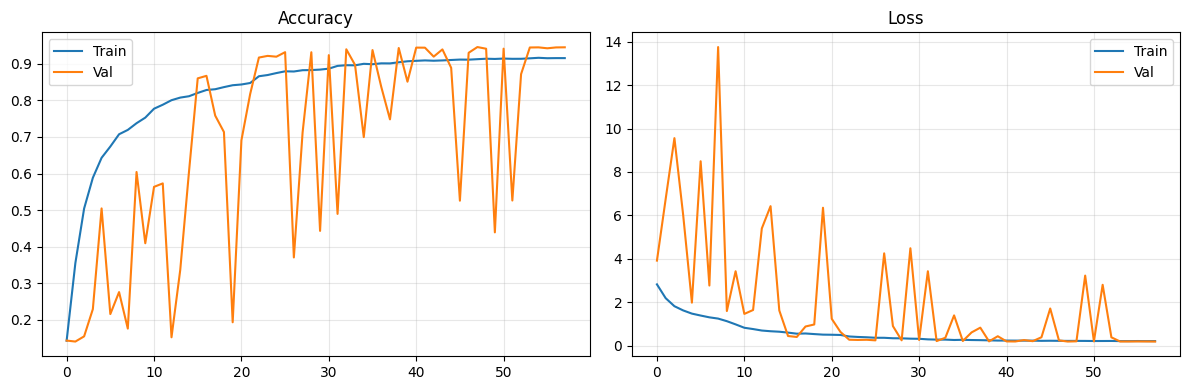

              precision    recall  f1-score   support

         ain       0.95      0.88      0.91       328
        alef       0.98      0.98      0.98       246
         beh       0.95      0.95      0.95       328
         dad       1.00      0.98      0.99        60
         dal       0.81      0.90      0.85       164
         feh       0.93      0.91      0.92       325
       ghain       0.97      1.00      0.98        60
         hah       1.00      1.00      1.00        60
         heh       0.94      0.94      0.94       326
        jeem       0.98      0.96      0.97       328
         kaf       0.97      0.94      0.95       328
        khah       1.00      0.97      0.98        60
         lam       0.94      0.93      0.94       410
        meem       0.88      0.95      0.91       328
        noon       0.93      0.93      0.93       325
         qaf       0.93      0.91      0.92       326
         reh       0.86      0.96      0.91       164
         sad       0.94    

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

present = sorted(np.unique(np.concatenate([y_test, preds])))
print(classification_report(
    y_test, preds,
    labels=present,
    target_names=[le.classes_[i] for i in present]
))

## Cell 7 — YOLO: Convert Labels to Single Class

In [13]:
def convert_to_single_class(dataset_dir):
    for split in ['train', 'val']:
        labels_dir = Path(dataset_dir) / split / 'labels'
        if not labels_dir.exists():
            print(f"  Skipping {split} — not found")
            continue
        count = 0
        for txt in labels_dir.glob('*.txt'):
            lines = txt.read_text().splitlines()
            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = '0'
                    new_lines.append(' '.join(parts))
            txt.write_text('\n'.join(new_lines) + '\n')
            count += 1
        print(f"  {split}: converted {count} label files")

print("Converting YOLO labels to single class...")
convert_to_single_class(MY_DATASET)

train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
print(f"Train: {len(train_imgs)}  Val: {len(val_imgs)}")

Converting YOLO labels to single class...
  train: converted 60 label files
  val: converted 13 label files
Train: 60  Val: 13


## Cell 8 — YOLO: Write data.yaml

In [14]:
yaml_path = MY_DATASET / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(f"path: {MY_DATASET.as_posix()}\n")
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write("nc: 1\n")
    f.write("names:\n  - character\n")
print(open(yaml_path).read())

path: F:/bach2/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images
nc: 1
names:
  - character



## Cell 9 — YOLO: Train

In [17]:
yolo_model = YOLO('yolov8s.pt')
yolo_model.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=640,
    batch=2,
    patience=50,
    device='cpu',
    project=str(ROOT / 'my_yolo'),
    name='char_detector',
    exist_ok=True,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
)

YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'
print(f"\nYOLO done. Weights exist: {YOLO_WEIGHTS.exists()}")

New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.26  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0

## Cell 10 — Load Models for Inference

In [18]:
YOLO_WEIGHTS  = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'

cnn_model     = load_model('arabic_cnn_final.keras')
yolo_detector = YOLO(str(YOLO_WEIGHTS))
label_classes = np.load('label_classes_final.npy', allow_pickle=True)

print(f"CNN input shape : {cnn_model.input_shape}")
print(f"CNN output shape: {cnn_model.output_shape}")
print(f"Label classes   : {list(label_classes)}")
print(f"YOLO loaded     : {YOLO_WEIGHTS}")

CNN input shape : (None, 32, 32, 3)
CNN output shape: (None, 28)
Label classes   : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]
YOLO loaded     : F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_yolo\char_detector\weights\best.pt


## Cell 11 — Preprocessing & Inference Functions

In [29]:
def preprocess_crop(crop_bgr):
    """Convert YOLO crop to 32x32 BGR for CNN."""
    gray    = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    x_min, y_min =  np.inf,  np.inf
    x_max, y_max = -np.inf, -np.inf
    for c in cnts:
        if cv2.contourArea(c) > 10:
            x, y, w, h = cv2.boundingRect(c)
            x_min = min(x_min, x);     y_min = min(y_min, y)
            x_max = max(x_max, x + w); y_max = max(y_max, y + h)
    if np.isinf(x_min):
        return None
    roi = thresh[int(y_min):int(y_max), int(x_min):int(x_max)]
    if roi.size == 0:
        return None
    h, w   = roi.shape
    side   = int(max(h, w) * 1.4)
    canvas = np.zeros((side, side), dtype='uint8')
    canvas[(side-h)//2:(side-h)//2+h, (side-w)//2:(side-w)//2+w] = roi
    resized   = cv2.resize(canvas, (32, 32), interpolation=cv2.INTER_AREA)
    final_bgr = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    return np.expand_dims(final_bgr.astype('float32') / 255.0, axis=0)


def recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W      = img.shape[:2]
    annotated = img.copy()

    results = yolo_detector(
        img, conf=conf_threshold, iou=iou_threshold, verbose=False
    )[0]

    if len(results.boxes) == 0:
        print("No characters detected.")
        return [], annotated

    detections = []
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = img[max(0,y1):min(H,y2), max(0,x1):min(W,x2)]
        if crop.size == 0:
            continue

        inp = preprocess_crop(crop)
        if inp is None:
            continue

        preds = cnn_model.predict(inp, verbose=0)[0]
        idx   = np.argmax(preds)
        label = str(label_classes[idx])
        conf  = float(preds[idx])
        detections.append((x1, y1, x2, y2, label, conf))

    # Sort right-to-left (Arabic)
    detections.sort(key=lambda d: -d[0])

    chars = []
    for (x1, y1, x2, y2, label, conf) in detections:
        chars.append(label)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(
            annotated, f"{label} {conf:.0%}",
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 1
        )

    return chars, annotated


print("Pipeline ready.")

Pipeline ready.


## Cell 12 — Test on Single Image

Detected (right → left): ['ghain', 'dad', 'teh']
Word: ghain dad teh


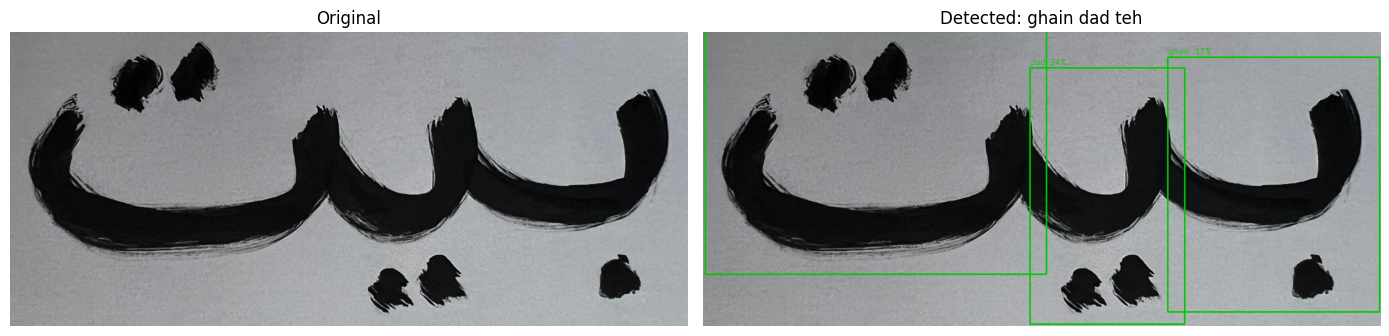

In [30]:
TEST_IMAGE = str(ROOT / 'word_test.png')  # change to your test image

chars, annotated = recognize_word(TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4)

print(f"Detected (right → left): {chars}")
print(f"Word: {' '.join(chars)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {" ".join(chars)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Cell 13 — Debug: Show Each Crop & CNN Prediction

In [31]:
def debug_cnn_predictions():
    """Test CNN on 100 random test images to diagnose single-class bias."""
    import random
    
    print(f"Testing CNN on random test samples...")
    print(f"Model classes: {list(label_classes)}")
    print(f"Total classes: {len(label_classes)}\n")
    
    # Test on subset of test data
    n_samples = min(100, len(X_test))
    indices = random.sample(range(len(X_test)), n_samples)
    
    true_labels = [le.classes_[y_test[i]] for i in indices]
    pred_probs = cnn_model.predict(X_test[indices], verbose=0)
    pred_labels = [label_classes[np.argmax(p)] for p in pred_probs]
    
    # Distribution of predictions
    from collections import Counter
    pred_dist = Counter(pred_labels)
    true_dist = Counter(true_labels)
    
    print(f"TRUE distribution (first {n_samples} test samples):")
    for label, count in true_dist.most_common():
        print(f"  {label}: {count}")
    
    print(f"\nPREDICTED distribution:")
    for label, count in pred_dist.most_common():
        print(f"  {label}: {count}")
    
    print(f"\nUnique classes predicted: {len(pred_dist)}/{len(label_classes)}")
    
    if len(pred_dist) == 1:
        print("\n⚠️  CRITICAL: Model is predicting ONLY ONE CLASS!")
        only_pred = list(pred_dist.keys())[0]
        print(f"   All predictions are: {only_pred}")
        
        # Show what the model is confidently saying
        print(f"\n   Sample confidences (top-5 classes):")
        for prob_row in pred_probs[:5]:
            top_5_idx = np.argsort(prob_row)[-5:][::-1]
            for idx in top_5_idx:
                print(f"     {label_classes[idx]}: {prob_row[idx]:.4f}")
            print()
    else:
        print(f"\n✓ Model is predicting multiple classes")
    
    return pred_dist, true_dist


debug_cnn_predictions()

Testing CNN on random test samples...
Model classes: [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]
Total classes: 28

TRUE distribution (first 100 test samples):
  lam: 12
  kaf: 9
  qaf: 9
  tah: 7
  feh: 7
  seen: 6
  alef: 6
  meem: 6
  beh: 5
  noon: 4
  reh: 4
  ain: 4
  yeh: 3
  sad: 3
  dal: 3
  heh: 3
  teh: 2
  jeem: 2
  khah: 1
  waw: 1
  sheen: 1
  zain: 1
  ghain: 1

PREDICTED distribution:
  lam: 13
  qaf: 10
  kaf: 9
  seen: 7
  feh: 7
  tah: 6
  meem: 6
  alef: 5
  dal: 5
  beh: 5
  noon: 4
  yeh: 3
  ain: 3
  reh: 3
  heh: 3
  teh: 2
  sad: 2
  jeem: 2
  khah: 1

(Counter({np.str_('lam'): 13,
          np.str_('qaf'): 10,
          np.str_('kaf'): 9,
          np.str_('seen'): 7,
          np.str_('feh'): 7,
          np.str_('tah'): 6,
          np.str_('meem'): 6,
          np.str_('alef'): 5,
          np.str_('dal'): 5,
          np.str_('beh'): 5,
          np.str_('noon'): 4,
          np.str_('yeh'): 3,
          np.str_('ain'): 3,
          np.str_('reh'): 3,
          np.str_('heh'): 3,
          np.str_('teh'): 2,
          np.str_('sad'): 2,
          np.str_('jeem'): 2,
          np.str_('khah'): 1,
          np.str_('waw'): 1,
          np.str_('sheen'): 1,
          np.str_('thal'): 1,
          np.str_('ghain'): 1}),
 Counter({np.str_('lam'): 12,
          np.str_('kaf'): 9,
          np.str_('qaf'): 9,
          np.str_('tah'): 7,
          np.str_('feh'): 7,
          np.str_('seen'): 6,
          np.str_('alef'): 6,
          np.str_('meem'): 6,
          np.str_('beh'): 5,
          np.str_('noon'): 4,
          np.str_('reh'

## Cell 14 — Test on All Val Images

Testing on 13 val images...

ce0882a8-WhatsApp_Image_2026-03-23_at_2.21.24_AM_8.jpeg: hah zah zain


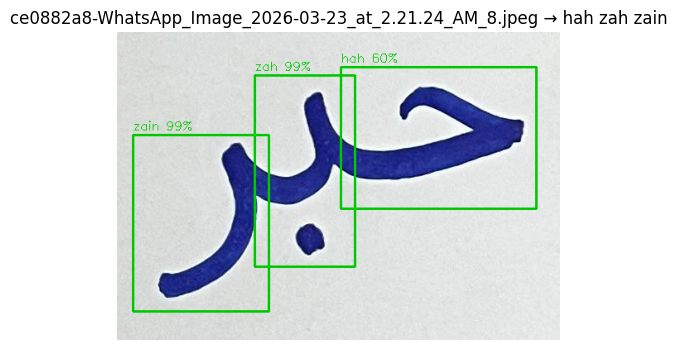

d272ef07-WhatsApp_Image_2026-03-23_at_2.21.26_AM_25.jpeg: dad zah ghain


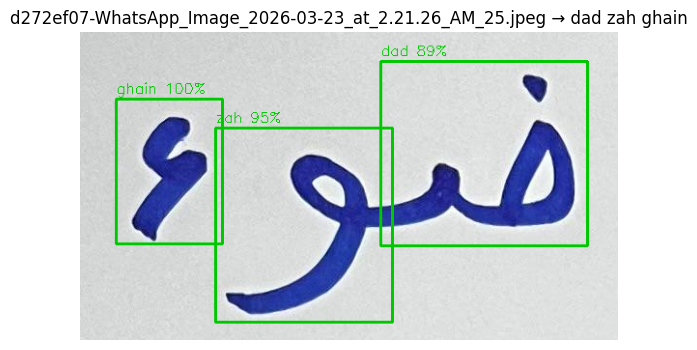

da1fee74-WhatsApp_Image_2026-03-23_at_2.21.26_AM_18.jpeg: hah zah sheen


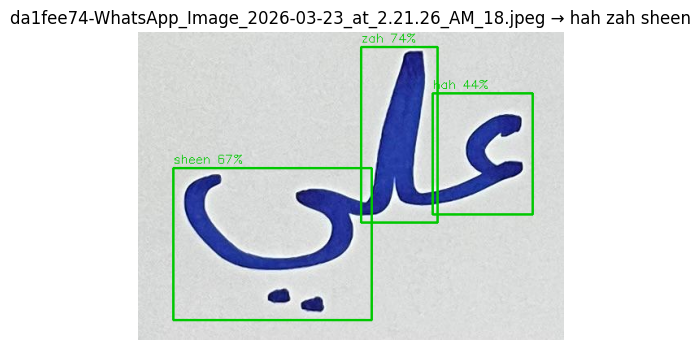

dd921431-WhatsApp_Image_2026-03-23_at_2.21.26_AM_20.jpeg: dad lam ghain ghain


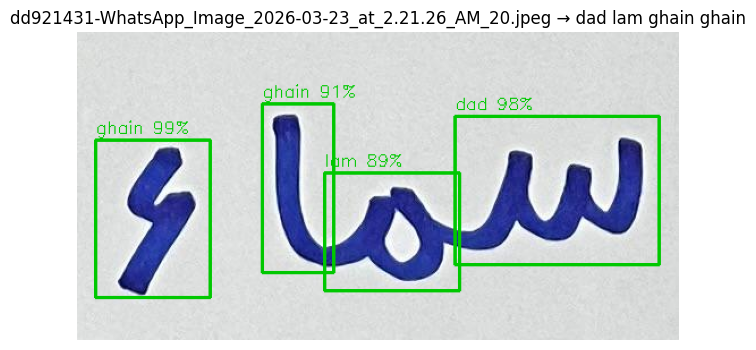

e05f66fa-WhatsApp_Image_2026-03-23_at_2.21.26_AM_9.jpeg: noon ghain ghain


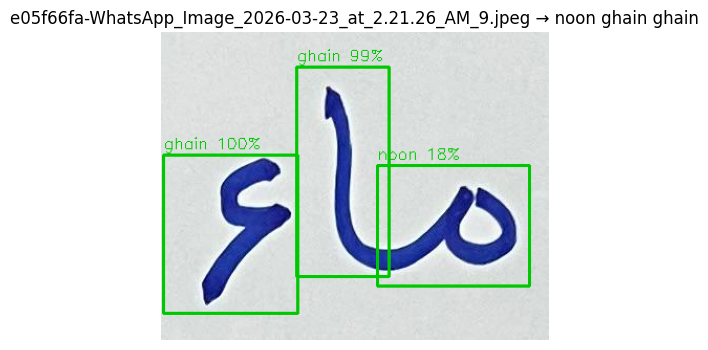

e47bdbbb-WhatsApp_Image_2026-03-23_at_2.21.26_AM_47.jpeg: khah zain


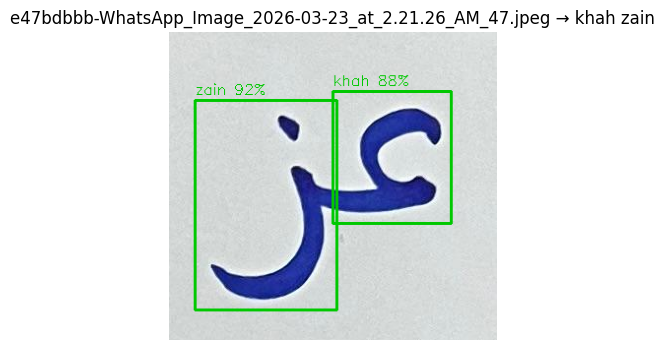

e8f36542-WhatsApp_Image_2026-03-23_at_2.21.26_AM_21.jpeg: thal teh


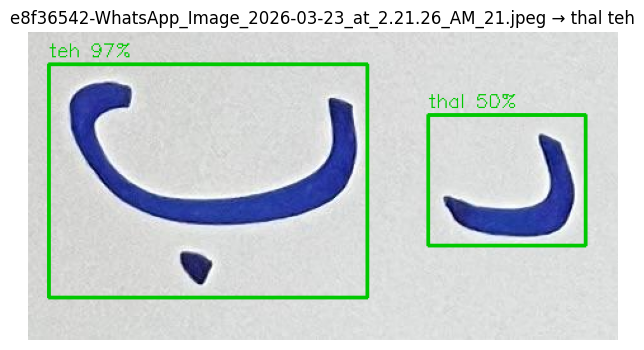

ee3eef31-WhatsApp_Image_2026-03-23_at_2.21.26_AM_40.jpeg: thal thal dad


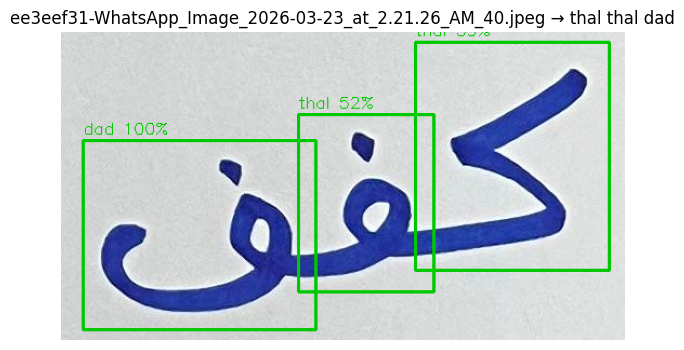

ef978434-WhatsApp_Image_2026-03-23_at_2.21.24_AM_1.jpeg: dad dad teh


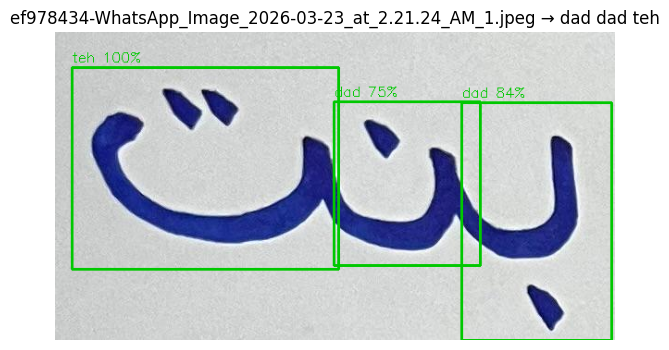

f1769f84-WhatsApp_Image_2026-03-23_at_2.21.26_AM_11.jpeg: dad ghain dad


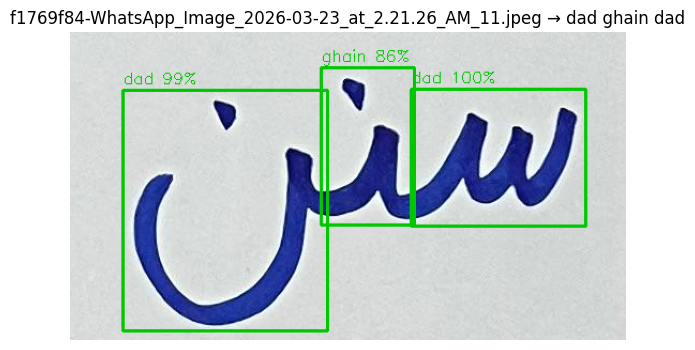

f2491bc4-WhatsApp_Image_2026-03-23_at_2.21.24_AM_3.jpeg: qaf ghain zah


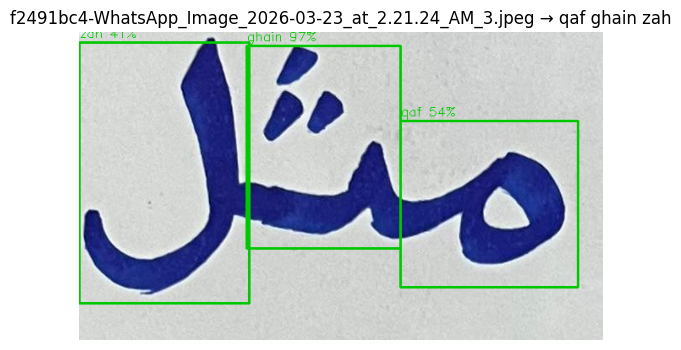

f84cf9b6-WhatsApp_Image_2026-03-23_at_2.21.26_AM_46.jpeg: zah hah zah khah


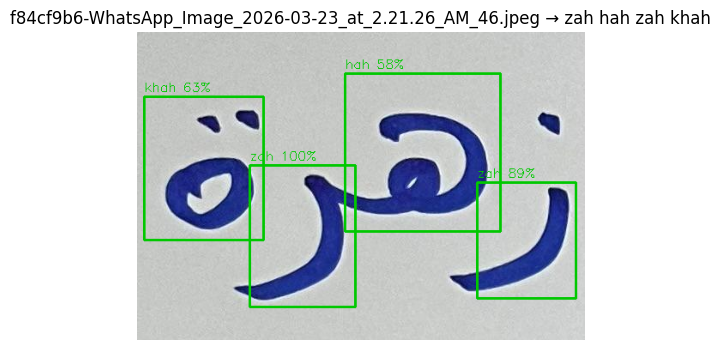

ffef08bc-WhatsApp_Image_2026-03-23_at_2.21.26_AM_34.jpeg: zain lam dad


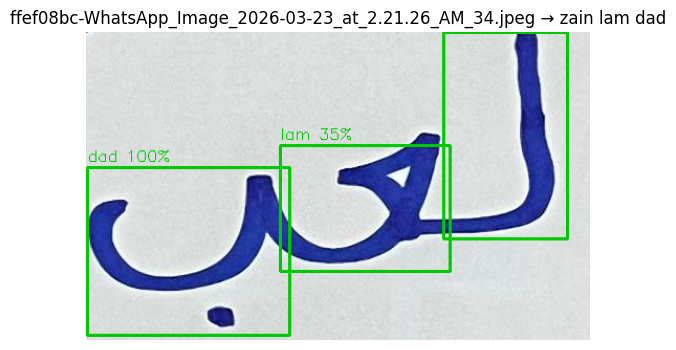

In [32]:
val_images = list((MY_DATASET / 'val' / 'images').glob('*.*'))
print(f"Testing on {len(val_images)} val images...\n")

for img_path in val_images:
    try:
        chars, annotated = recognize_word(str(img_path), conf_threshold=0.25)
        print(f"{img_path.name}: {' '.join(chars)}")
        plt.figure(figsize=(10, 4))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"{img_path.name} → {' '.join(chars)}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error on {img_path.name}: {e}")